In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [23]:
np.random.seed(42)
n=500

time = np.linspace(0,10,n)

df = pd.DataFrame({
    "time": time,
    "accel_x": np.sin(time) + np.random.normal(0,0.1,n),
    "accel_y": np.cos(time) + np.random.normal(0,0.1,n),
    "accel_z": np.random.normal(9.8,0.2,n),
    "gyro_x":  np.random.normal(0,0.5,n),
    "gyro_y":  np.random.normal(0,0.5,n),
})

print(df.shape)
df.head()


(500, 6)


,time,accel_x,accel_y,accel_z,gyro_x,gyro_y
0,0.00000,0.049671,1.092618,10.079871,0.389181,-0.337589
1,0.02004,0.006212,1.190741,9.984927,-0.275593,-0.072259
2,0.04008,0.104838,0.859340,9.811926,-0.409099,-0.396210
3,0.06012,0.212387,1.054490,9.670613,-0.001687,-0.153981
4,0.08016,0.056659,0.931725,9.939645,-0.085092,-0.946807


In [24]:
print("Shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

df.describe()

Shape: (500, 6)

Data types:
time       float64
accel_x    float64
accel_y    float64
accel_z    float64
gyro_x     float64
gyro_y     float64
dtype: object

Missing values:
time       0
accel_x    0
accel_y    0
accel_z    0
gyro_x     0
gyro_y     0
dtype: int64


,time,accel_x,accel_y,accel_z,gyro_x,gyro_y
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,5.000000,0.183673,-0.050948,9.821697,0.016594,-0.005758
std,2.895428,0.671380,0.730356,0.202049,0.492033,0.479783
min,0.000000,-1.202369,-1.246507,9.220749,-1.470194,-1.509756
25%,2.500000,-0.377384,-0.772982,9.679514,-0.305968,-0.330368
50%,5.000000,0.305161,-0.096328,9.823961,-0.004457,-0.001576
75%,7.500000,0.810988,0.675676,9.950948,0.349885,0.334588
max,10.000000,1.182909,1.215522,10.320337,1.596554,1.554959


In [25]:
df=df.dropna()

print("Rows after cleaning:", len(df))

df["accel_magnitude"]=np.sqrt(
    df["accel_x"]**2 +
    df["accel_y"]**2 +
    df["accel_z"]**2
)

df.head()

Rows after cleaning: 500


,time,accel_x,accel_y,accel_z,gyro_x,gyro_y,accel_magnitude
0,0.00000,0.049671,1.092618,10.079871,0.389181,-0.337589,10.139038
1,0.02004,0.006212,1.190741,9.984927,-0.275593,-0.072259,10.055678
2,0.04008,0.104838,0.859340,9.811926,-0.409099,-0.396210,9.850043
3,0.06012,0.212387,1.054490,9.670613,-0.001687,-0.153981,9.730252
4,0.08016,0.056659,0.931725,9.939645,-0.085092,-0.946807,9.983379


In [26]:
print("===Accelerometer Statistics===")
print(f"Mean accel_x:   {np.mean(df['accel_x']):.3f} m/s**2")
print(f"Std accel_x:    {np.std(df['accel_x']):.3f} m/s**2")
print(f"Max magnitude:  {np.max(df['accel_magnitude']):.3f} m/s**2")
print(f"Min magnitude:  {np.min(df['accel_magnitude']):.3f} m/s**2")
print(f"Mean magnitude: {np.mean(df['accel_magnitude']):.3f} m/s**2")

print("\n===Gyroscope Statistics===")
for axis in ['gyro_x', 'gyro_y']:
  print(f"{axis} - mean : {np.mean(df[axis]):.3f}, std: {np.std(df[axis]):.3f}")



===Accelerometer Statistics===
Mean accel_x:   0.184 m/s**2
Std accel_x:    0.671 m/s**2
Max magnitude:  10.375 m/s**2
Min magnitude:  9.276 m/s**2
Mean magnitude: 9.873 m/s**2

===Gyroscope Statistics===
gyro_x - mean : 0.017, std: 0.492
gyro_y - mean : -0.006, std: 0.479


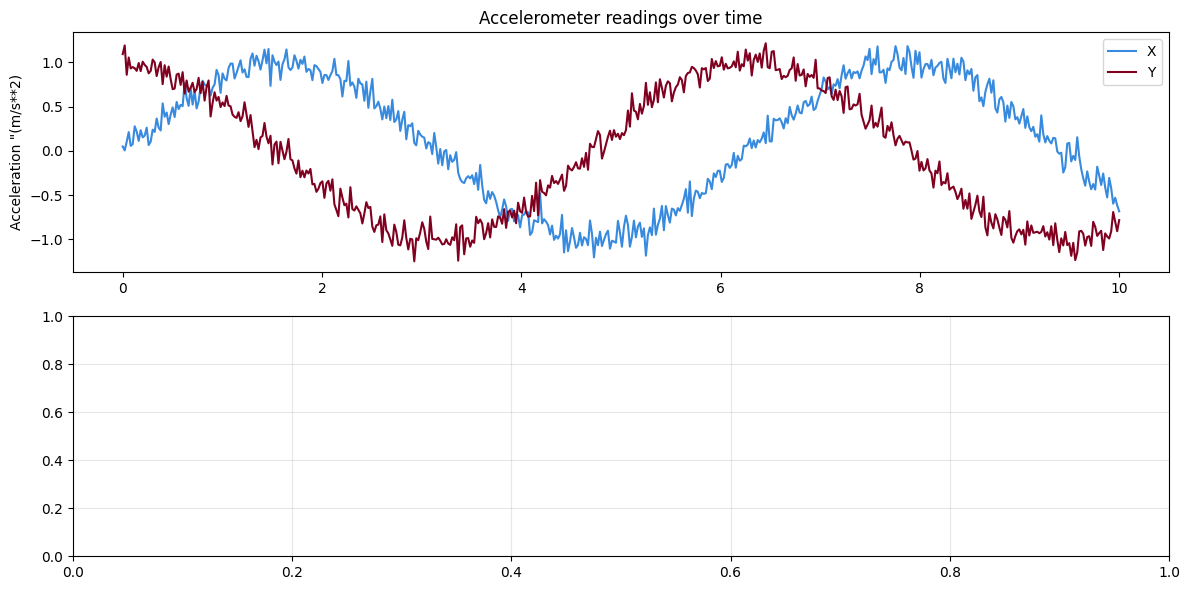

In [27]:
fig, axes = plt.subplots(2,1, figsize=(12, 6))

axes[0].plot(df['time'], df['accel_x'], label='X', color='#378ADD')
axes[0].plot(df['time'], df['accel_y'], label='Y', color='#800020')
axes[0].set_title('Accelerometer readings over time')
axes[0].set_ylabel('Acceleration "(m/s**2)')
axes[0].legend()
axes[1].grid(True,alpha=0.3)

plt.tight_layout()
plt.savefig('plot1_timeseries.png', dpi=150)
plt.show()


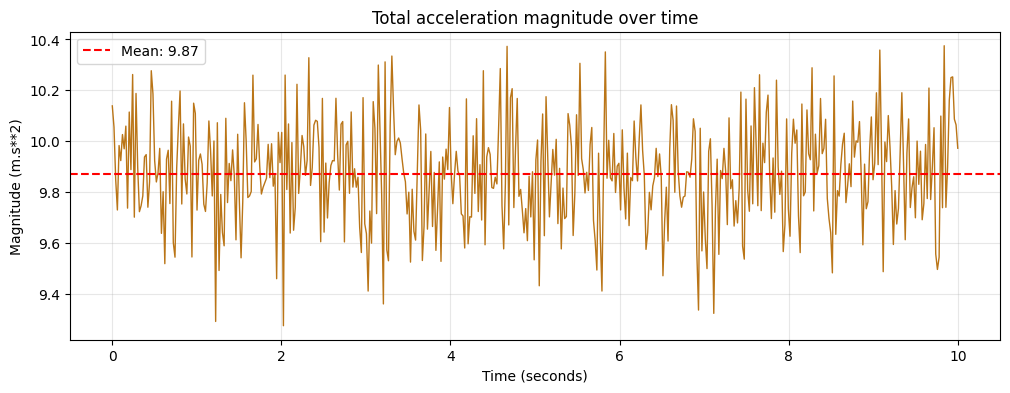

In [28]:
plt.figure(figsize=(12,4))
plt.plot(df['time'], df['accel_magnitude'], color='#BA7517', linewidth=1)
plt.axhline(y=df['accel_magnitude'].mean(), color='red',
                 linestyle='--', label=f"Mean: {df['accel_magnitude'].mean():.2f}")
plt.title('Total acceleration magnitude over time')
plt.xlabel('Time (seconds)')
plt.ylabel('Magnitude (m.s**2)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('plot2_magnitude.png', dpi=150)
plt.show()


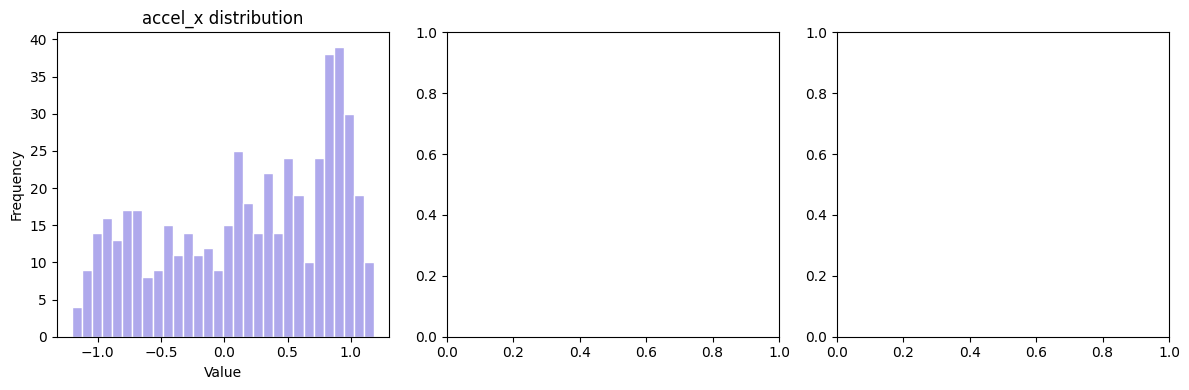

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [29]:
fig,axes=plt.subplots(1,3,figsize=(12,4))

for i, col in enumerate(['accel_x', 'accel_y', 'accel_z']):
  axes[i].hist(df[col], bins=30, color='#AFA9EC', edgecolor='white')
  axes[i].set_title(f'{col} distribution')
  axes[i].set_xlabel('Value')
  axes[i].set_ylabel('Frequency')

  plt.tight_layout()
  plt.savefig('plot3_histogram.png', dpi=150)
  plt.show()

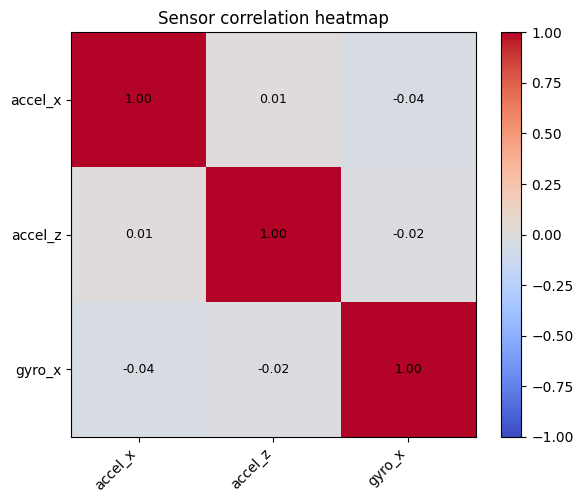

In [30]:
correlation=df[['accel_x','accel_z','gyro_x']].corr()

fig, ax=plt.subplots(figsize=(6,5))
im = ax.imshow(correlation, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im)

# Correct cols to match the dimensions of the correlation matrix
cols_for_correlation = correlation.columns.tolist()
ax.set_xticks(range(len(cols_for_correlation)))
ax.set_yticks(range(len(cols_for_correlation)))
ax.set_xticklabels(cols_for_correlation, rotation=45, ha='right')
ax.set_yticklabels(cols_for_correlation)

for i in range(len(cols_for_correlation)):
  for j in range(len(cols_for_correlation)):
    ax.text(j,i, f'{correlation.iloc[i,j]:.2f}',
            ha='center', va='center', fontsize=9)

ax.set_title('Sensor correlation heatmap')
plt.tight_layout()
plt.savefig('plot4_heatmap.png', dpi=150)
plt.show()

In [33]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy('plot1_timeseries.png', '/content/drive/MyDrive/plot1_timeseries.png')
shutil.copy('plot2_magnitude.png', '/content/drive/MyDrive/plot2_magnitude.png')
shutil.copy('plot3_histogram.png', '/content/drive/MyDrive/plot3_histogram.png')
shutil.copy('plot4_heatmap.png', '/content/drive/MyDrive/plot4_heatmap.png')

print("All plots saved to Google Drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All plots saved to Google Drive


In [37]:
summary = f"""
=== ROBOT SENSOR DATA EXPLORER - PROJECT SUMMARY ===

Dataset: Simulated IMU sensor data(500 readings over 10 seconds)
Sensors: Accelerometer (X,Y,Z) + Gyroscope (X,Y)

Key findings:
- Mean acceleration magnitude: {np.mean(df['accel_magnitude']):.3f} m/s**2
- Max acceleration magnitude: {np.max(df['accel_magnitude']):.3f} m/s**2
- accel_z mean = 9.8 m.s**2 (gravity confirmed in data)
- Gyroscope readings centred near 0 (robot at rest)

Charts produced:
-plot1_timeseries.png >> sensor readings over time
-plot2_magnitude.png >> total acceleration magnitude
-plot3_histogram.png >> sensor value distributions
-plot4-heatmap.png >> sensor correlation matrix

Tools used: NumPy, Pandas, Matplotlib
"""

print(summary)



=== ROBOT SENSOR DATA EXPLORER - PROJECT SUMMARY ===

Dataset: Simulated IMU sensor data(500 readings over 10 seconds)
Sensors: Accelerometer (X,Y,Z) + Gyroscope (X,Y)

Key findings:
- Mean acceleration magnitude: 9.873 m/s**2
- Max acceleration magnitude: 10.375 m/s**2
- accel_z mean = 9.8 m.s**2 (gravity confirmed in data)
- Gyroscope readings centred near 0 (robot at rest)

Charts produced:
-plot1_timeseries.png >> sensor readings over time
-plot2_magnitude.png >> total acceleration magnitude
-plot3_histogram.png >> sensor value distributions
-plot4-heatmap.png >> sensor correlation matrix

Tools used: NumPy, Pandas, Matplotlib

